In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
df_test = pd.read_csv("../generated/test_predictions.csv")
# df_val = pd.read_csv("../generated/val_predictions.csv")
# df_train = pd.read_csv("../generated/train_predictions.csv")

In [3]:
# Scatter with ols regression line
date = 202105
px.scatter(df_test[df_test["yyyymm"] == date], x="ret_1m", y="rank_score", title=f"ret_1m vs rank_score for {date}", trendline="ols")

ValueError: Value of 'y' is not the name of a column in 'data_frame'. Expected one of ['permno', 'yyyymm', 'ret', 'ret_1m', 'ret_3m', 'ret_6m', 'AbnormalAccruals', 'Accruals', 'AccrualsBM', 'Activism1', 'AM', 'AnalystRevision', 'AnnouncementReturn', 'AssetGrowth', 'BetaLiquidityPS', 'BetaTailRisk', 'betaVIX', 'BM', 'BMdec', 'BookLeverage', 'BPEBM', 'Cash', 'CashProd', 'CBOperProf', 'CF', 'cfp', 'ChangeInRecommendation', 'ChAssetTurnover', 'ChEQ', 'ChForecastAccrual', 'ChInv', 'ChInvIA', 'ChNNCOA', 'ChNWC', 'ChTax', 'CompEquIss', 'CompositeDebtIssuance', 'ConvDebt', 'CoskewACX', 'CPVolSpread', 'dVolCall', 'dVolPut', 'dCPVolSpread', 'CredRatDG', 'CustomerMomentum', 'DelBreadth', 'DelCOA', 'DelCOL', 'DelEqu', 'DelFINL', 'DelLTI', 'DelNetFin', 'DivInit', 'DivOmit', 'DivSeason', 'DivYieldST', 'dNoa', 'DolVol', 'EarningsConsistency', 'EarningsForecastDisparity', 'EarningsStreak', 'EarningsSurprise', 'EarnSupBig', 'EBM', 'EntMult', 'EP', 'EquityDuration', 'ExchSwitch', 'ExclExp', 'FEPS', 'fgr

In [36]:
# Add columns for ranking based on ret1m and rank_score, and compare them
df_test["rank_ret_1m"] = df_test.groupby("yyyymm")["ret_1m"].rank(ascending=False)
df_test["rank_rank_score"] = df_test.groupby("yyyymm")["rank_score"].rank(ascending=False)
px.scatter(df_test[df_test["yyyymm"] == date], x="rank_ret_1m", y="rank_rank_score", title=f"Rank ret_1m vs rank_score for {date}", trendline="ols")

<Axes: >

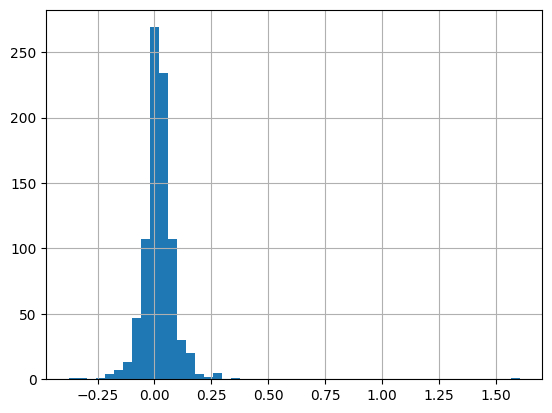

In [41]:
df_test[df_test["yyyymm"] == date].ret.hist(bins=50)

In [51]:
# Top 10 predicted for a given month
top_10 = df_test[df_test["yyyymm"] == date].nlargest(10, "rank_score")
px.scatter(top_10, x="ret_1m", y="rank_score", title=f"Top 10 predicted for {date}", trendline="ols")

In [53]:
top_10[["permno", "ret_1m", "rank_score", "rank_ret_1m", "rank_rank_score"]]

,permno,ret_1m,rank_score,rank_ret_1m,rank_rank_score
3608,27422,0.071571,851.7,143.0,1.0
3309,10200,0.093149,844.7,101.0,2.5
4064,90776,0.054837,844.7,203.0,2.5
3790,77520,0.043222,840.4,238.0,4.0
3503,18136,0.233060,837.9,15.0,5.0
3368,13527,0.049696,836.6,215.0,6.0
3404,14328,1.169985,835.0,1.0,7.0
3831,80928,-0.014023,834.3,552.0,8.0
4023,89692,0.023370,832.4,310.0,9.0
3859,82779,0.438220,830.6,3.0,10.0


In [54]:
df_features = pd.read_parquet("../data/signal_doc.parquet")

In [67]:
_temp = df_features[df_features["Acronym"].isin(list(set(df_train.columns) & set(df_features.Acronym.values)))].reset_index().drop(columns=["index"])

In [78]:
df_test.corr()["ret_1m"].sort_values(ascending=False, key=abs).head(20)

ret_1m               1.000000
rank_ret_1m         -0.780292
IO_ShortInterest    -0.556544
dVolPut              0.209429
dVolCall             0.178641
sfe                 -0.158106
IndRetBig           -0.136303
EarnSupBig          -0.134390
iomom_supp          -0.118817
iomom_cust          -0.113343
rank_rank_score     -0.085136
MRreversal          -0.083925
RIO_Volatility       0.073014
rank_score           0.072006
PS                  -0.071378
Beta                 0.069299
MomSeason06YrPlus    0.068113
retConglomerate     -0.067551
MomRev               0.065568
BetaFP               0.060995
Name: ret_1m, dtype: float64

In [80]:
features_importance = {'ret_1m': {'AbnormalAccruals': 0.6860435605049133, 'Accruals': 0.6477928161621094, 'AccrualsBM': 0.4166221022605896, 'AM': 0.9925887584686279, 'AnalystRevision': 0.6789274215698242, 'AnnouncementReturn': 0.6039931178092957, 'AssetGrowth': 0.5969497561454773, 'BetaLiquidityPS': 0.6785217523574829, 'BetaTailRisk': 0.6051580905914307, 'betaVIX': 0.6129378080368042, 'BM': 0.8909403681755066, 'BMdec': 0.7343803644180298, 'BookLeverage': 0.8435753583908081, 'BPEBM': 0.5064755082130432, 'Cash': 0.684737503528595, 'CashProd': 0.8625766038894653, 'CBOperProf': 0.7222607731819153, 'CF': 0.8500329256057739, 'cfp': 0.6024268865585327, 'ChangeInRecommendation': 0.4865863621234894, 'ChAssetTurnover': 0.6248568892478943, 'ChEQ': 0.5701785087585449, 'ChForecastAccrual': 0.8339846730232239, 'ChInv': 2.338724136352539, 'ChInvIA': 0.5436660051345825, 'ChNNCOA': 0.45217806100845337, 'ChNWC': 0.6161537766456604, 'ChTax': 0.5193949937820435, 'CompEquIss': 0.594330370426178, 'CompositeDebtIssuance': 0.6240660548210144, 'CoskewACX': 0.7501212358474731, 'CPVolSpread': 0.6005950570106506, 'dVolCall': 0.9476600885391235, 'dVolPut': 0.7457236051559448, 'dCPVolSpread': 0.6861523389816284, 'CustomerMomentum': 0.9499553442001343, 'DelBreadth': 0.6323484182357788, 'DelCOA': 0.5685549974441528, 'DelCOL': 0.5780325531959534, 'DelEqu': 0.6968607306480408, 'DelFINL': 0.773689866065979, 'DelLTI': 0.5343267917633057, 'DelNetFin': 0.6472198963165283, 'DivSeason': 1.4365243911743164, 'DivYieldST': 1.3935154676437378, 'dNoa': 0.6243696212768555, 'DolVol': 1.0989315509796143, 'EarningsConsistency': 0.6812189221382141, 'EarningsForecastDisparity': 0.38657957315444946, 'EarningsStreak': 0.775898277759552, 'EarningsSurprise': 0.6859800815582275, 'EBM': 0.8235185742378235, 'EntMult': 0.6140043139457703, 'EP': 0.7638292908668518, 'EquityDuration': 0.6388289928436279, 'ExclExp': 0.7063688039779663, 'FEPS': 0.7064220309257507, 'fgr5yrLag': 0.6549649238586426, 'FirmAgeMom': 0.4903669059276581, 'ForecastDispersion': 0.4990890920162201, 'Frontier': 0.5135090351104736, 'Governance': 1.1406326293945312, 'GP': 1.2376266717910767, 'GrAdExp': 0.5536552667617798, 'grcapx': 0.6557545065879822, 'grcapx3y': 0.5515076518058777, 'Herf': 1.1028616428375244, 'HerfBE': 0.5334947109222412, 'hire': 0.8103620409965515, 'IdioVol3F': 1.0522732734680176, 'IdioVolAHT': 1.7956185340881348, 'Illiquidity': 2.9159255027770996, 'IndMom': 0.6724947690963745, 'IndRetBig': 1.537872314453125, 'IntanBM': 0.6623628735542297, 'IntanCFP': 0.7423201203346252, 'IntanEP': 0.7673571109771729, 'IntanSP': 0.8348962068557739, 'IntMom': 0.6838260293006897, 'Investment': 0.5186816453933716, 'InvestPPEInv': 0.4975326359272003, 'InvGrowth': 0.868232011795044, 'iomom_cust': 0.7232264876365662, 'iomom_supp': 0.529340386390686, 'Leverage': 0.5750164985656738, 'LRreversal': 0.5382848381996155, 'MaxRet': 0.893798291683197, 'MeanRankRevGrowth': 0.7508459687232971, 'Mom12m': 0.9531526565551758, 'Mom12mOffSeason': 0.6505444645881653, 'Mom6m': 0.702634334564209, 'Mom6mJunk': 0.5876343250274658, 'MomOffSeason': 0.6029792428016663, 'MomOffSeason06YrPlus': 0.8231837749481201, 'MomOffSeason16YrPlus': 0.8083138465881348, 'MomRev': 0.2220819592475891, 'MomSeason': 0.6926245093345642, 'MomSeason06YrPlus': 0.5372359752655029, 'MomSeason11YrPlus': 0.7141349911689758, 'MomSeason16YrPlus': 0.7630137801170349, 'MomSeasonShort': 0.627651035785675, 'MomVol': 0.6994345188140869, 'MS': 0.7603247165679932, 'NetDebtFinance': 0.5850355625152588, 'NetDebtPrice': 0.6584540605545044, 'NetEquityFinance': 0.5522037148475647, 'NetPayoutYield': 0.5113999247550964, 'NOA': 0.6000918745994568, 'OPLeverage': 0.9017702341079712, 'OptionVolume1': 1.0017404556274414, 'OrderBacklog': 0.7542910575866699, 'OrderBacklogChg': 0.6433759927749634, 'OrgCap': 0.4350808560848236, 'PayoutYield': 0.5857375860214233, 'PctAcc': 0.45832255482673645, 'PctTotAcc': 0.5860693454742432, 'Price': 1.4659552574157715, 'PriceDelayRsq': 0.5392789244651794, 'RD': 0.8112537860870361, 'RDAbility': 0.6491970419883728, 'RDIPO': 0.4731552004814148, 'RDS': 0.5961939096450806, 'RealizedVol': 1.4216177463531494, 'ResidualMomentum': 0.45691776275634766, 'retConglomerate': 0.519342303276062, 'ReturnSkew': 0.5571857690811157, 'ReturnSkew3F': 0.6563515067100525, 'REV6': 0.7849351167678833, 'RevenueSurprise': 0.6232898831367493, 'RIO_Disp': 0.6596206426620483, 'RIO_Turnover': 7.968476295471191, 'RIVolSpread': 0.6428757905960083, 'roaq': 0.6879931092262268, 'ShareIss1Y': 0.6181058883666992, 'ShareIss5Y': 0.5935066938400269, 'ShareVol': 0.8713522553443909, 'Size': 11.899654388427734, 'SmileSlope': 0.6459094285964966, 'STreversal': 0.627013087272644, 'tang': 0.634381115436554, 'Tax': 0.6515381336212158, 'TotalAccruals': 0.7552857995033264, 'TrendFactor': 0.7645373940467834, 'VolSD': 0.9475731253623962, 'XFIN': 0.5351400971412659, 'zerotrade6M': 3.0449206829071045, 'zerotrade1M': 0.7906613349914551, 'zerotrade12M': 2.6325788497924805, 'Activism2': 0.32521486282348633, 'AdExp': 0.5601651668548584, 'AgeIPO': 0.586353063583374, 'AnalystValue': 0.766756534576416, 'AOP': 0.6924838423728943, 'Beta': 0.9521597027778625, 'BetaFP': 1.6545469760894775, 'BidAskSpread': 1.490323781967163, 'BrandInvest': 0.9272100329399109, 'ConsRecomm': 0.8652955293655396, 'Coskewness': 0.7016522884368896, 'DelDRC': 0.544079601764679, 'FirmAge': 0.9857598543167114, 'FR': 0.630992591381073, 'GrLTNOA': 0.5772056579589844, 'GrSaleToGrInv': 0.4863501191139221, 'GrSaleToGrOverhead': 0.5704243183135986, 'HerfAsset': 0.9129300117492676, 'High52': 0.6678365468978882, 'MomOffSeason11YrPlus': 0.8702784180641174, 'MRreversal': 0.5991284251213074, 'NumEarnIncrease': 0.682613730430603, 'OperProf': 0.7681803703308105, 'OperProfRD': 0.5204164981842041, 'OptionVolume2': 1.115027904510498, 'PredictedFE': 0.5209106206893921, 'PriceDelaySlope': 0.41171789169311523, 'PriceDelayTstat': 0.4523148536682129, 'realestate': 0.42419707775115967, 'RoE': 0.44249844551086426, 'ShareRepurchase': 0.9303990006446838, 'ShortInterest': 0.9857260584831238, 'sinAlgo': 0.38687872886657715, 'skew1': 0.5604910254478455, 'SP': 0.6365969777107239, 'VarCF': 0.4716198742389679, 'VolMkt': 1.5546128749847412, 'VolumeTrend': 0.6087705492973328}, 'ret_3m': {'AbnormalAccruals': 1.2234658002853394, 'Accruals': 1.0645620822906494, 'Activism1': 1.5617756843566895, 'AM': 1.5401475429534912, 'AnalystRevision': 0.8790685534477234, 'AnnouncementReturn': 0.7700996994972229, 'AssetGrowth': 0.9648230075836182, 'BetaLiquidityPS': 0.8303857445716858, 'BetaTailRisk': 0.7975910305976868, 'betaVIX': 0.9135727286338806, 'BM': 1.0934152603149414, 'BMdec': 0.8954597115516663, 'BookLeverage': 0.6332448720932007, 'BPEBM': 1.0669305324554443, 'Cash': 1.4537252187728882, 'CashProd': 0.768674910068512, 'CBOperProf': 1.6471381187438965, 'CF': 0.8844584822654724, 'cfp': 0.7656872868537903, 'ChangeInRecommendation': 0.6917731165885925, 'ChAssetTurnover': 0.8633127212524414, 'ChEQ': 1.012223720550537, 'ChForecastAccrual': 1.168471336364746, 'ChInv': 0.8053063154220581, 'ChInvIA': 0.9732128381729126, 'ChNNCOA': 0.8506867289543152, 'ChNWC': 0.7807679176330566, 'ChTax': 0.926655113697052, 'CompEquIss': 1.290113091468811, 'CompositeDebtIssuance': 1.1317652463912964, 'CoskewACX': 0.9547523260116577, 'CPVolSpread': 0.9703960418701172, 'dVolCall': 1.0169941186904907, 'dVolPut': 1.0995855331420898, 'dCPVolSpread': 1.025925636291504, 'CustomerMomentum': 0.9893213510513306, 'DelBreadth': 0.797004222869873, 'DelCOA': 0.8909083604812622, 'DelCOL': 0.5608664155006409, 'DelEqu': 1.072583556175232, 'DelFINL': 0.8160938024520874, 'DelLTI': 0.7435535192489624, 'DelNetFin': 0.6939714550971985, 'DivSeason': 0.016913771629333496, 'DivYieldST': 0.9664871692657471, 'dNoa': 0.8561793565750122, 'DolVol': 0.8393829464912415, 'EarningsConsistency': 0.5145342350006104, 'EarningsForecastDisparity': 0.7546000480651855, 'EarningsStreak': 0.9855385422706604, 'EarningsSurprise': 0.971859872341156, 'EBM': 1.4314032793045044, 'EntMult': 0.8468571305274963, 'EP': 0.8956391215324402, 'EquityDuration': 0.8463534712791443, 'ExclExp': 0.9531071186065674, 'FEPS': 0.7248663306236267, 'fgr5yrLag': 0.8659149408340454, 'FirmAgeMom': 1.2169324159622192, 'ForecastDispersion': 0.9270843267440796, 'Frontier': 0.9904994964599609, 'Governance': 0.5073755383491516, 'GP': 0.8224019408226013, 'GrAdExp': 1.045019507408142, 'grcapx': 0.9645743370056152, 'grcapx3y': 0.9159957766532898, 'Herf': 1.4746785163879395, 'HerfBE': 0.7973582148551941, 'hire': 0.753693163394928, 'IdioVol3F': 1.7631791830062866, 'IdioVolAHT': 1.1224305629730225, 'Illiquidity': 2.10406231880188, 'IndMom': 0.7768362760543823, 'IntanBM': 0.856061577796936, 'IntanCFP': 0.7386856079101562, 'IntanEP': 0.8308210968971252, 'IntanSP': 0.9121211767196655, 'IntMom': 0.8169594407081604, 'Investment': 0.7378799319267273, 'InvestPPEInv': 0.6960452198982239, 'InvGrowth': 0.729495644569397, 'iomom_cust': 0.9191860556602478, 'iomom_supp': 0.7969329357147217, 'Leverage': 2.1317968368530273, 'LRreversal': 0.8427550792694092, 'MaxRet': 0.8711862564086914, 'MeanRankRevGrowth': 0.887943685054779, 'Mom12m': 1.0546181201934814, 'Mom12mOffSeason': 1.2220169305801392, 'Mom6m': 1.0698301792144775, 'Mom6mJunk': 0.6681962609291077, 'MomOffSeason': 4.1929097175598145, 'MomOffSeason06YrPlus': 0.9674995541572571, 'MomOffSeason16YrPlus': 0.897833526134491, 'MomSeason': 0.7123697400093079, 'MomSeason06YrPlus': 0.9783031344413757, 'MomSeason11YrPlus': 1.0203059911727905, 'MomSeason16YrPlus': 0.7379577159881592, 'MomSeasonShort': 1.013709545135498, 'MomVol': 0.910953938961029, 'MS': 0.3469708561897278, 'NetDebtFinance': 1.0174620151519775, 'NetDebtPrice': 1.2566249370574951, 'NetEquityFinance': 0.7242690920829773, 'NetPayoutYield': 1.2772103548049927, 'NOA': 0.7739723324775696, 'OPLeverage': 0.8584099411964417, 'OptionVolume1': 0.7129881978034973, 'OrderBacklog': 0.8236777186393738, 'OrderBacklogChg': 0.9949621558189392, 'OrgCap': 0.5684878826141357, 'OScore': 0.15578818321228027, 'PayoutYield': 0.9908244013786316, 'PctAcc': 0.727843701839447, 'PctTotAcc': 0.8861932754516602, 'Price': 0.6074652671813965, 'PriceDelayRsq': 0.8762578964233398, 'RD': 1.0642284154891968, 'RDAbility': 0.9310518503189087, 'RDS': 0.9086663126945496, 'RealizedVol': 1.1366569995880127, 'ResidualMomentum': 0.9323911070823669, 'retConglomerate': 0.6531084179878235, 'ReturnSkew': 0.7665573358535767, 'ReturnSkew3F': 0.9447010159492493, 'REV6': 0.7740528583526611, 'RevenueSurprise': 0.9823501110076904, 'RIO_Disp': 2.6798095703125, 'RIO_MB': 0.5546993017196655, 'RIO_Turnover': 2.191063165664673, 'RIO_Volatility': 1.095805048942566, 'RIVolSpread': 0.8620047569274902, 'roaq': 1.047563910484314, 'sfe': 0.5767461061477661, 'ShareIss1Y': 0.9951494932174683, 'ShareIss5Y': 1.184614896774292, 'Size': 4.156376838684082, 'SmileSlope': 0.7464351058006287, 'STreversal': 0.8364715576171875, 'tang': 0.7432769536972046, 'Tax': 0.7212382555007935, 'TotalAccruals': 0.7998576760292053, 'TrendFactor': 0.9001282453536987, 'VolSD': 0.9970439076423645, 'XFIN': 0.8978859782218933, 'zerotrade6M': 2.1460766792297363, 'zerotrade1M': 0.9446064233779907, 'zerotrade12M': 2.5749850273132324, 'AdExp': 0.7836675643920898, 'AnalystValue': 0.7975481152534485, 'AOP': 0.6602572202682495, 'Beta': 1.1765962839126587, 'BetaFP': 0.8850662708282471, 'BidAskSpread': 1.2463029623031616, 'BrandInvest': 0.9903196096420288, 'ConsRecomm': 1.2363535165786743, 'Coskewness': 0.6289149522781372, 'DebtIssuance': 1.6042118072509766, 'DelDRC': 0.907170295715332, 'DownRecomm': 0.27831506729125977, 'FirmAge': 1.1015831232070923, 'FR': 0.640106737613678, 'GrLTNOA': 0.9845115542411804, 'GrSaleToGrInv': 0.9462032914161682, 'GrSaleToGrOverhead': 0.8974949717521667, 'HerfAsset': 1.044242262840271, 'High52': 0.827076256275177, 'MomOffSeason11YrPlus': 0.7238292098045349, 'MRreversal': 0.7333937883377075, 'NumEarnIncrease': 0.6450380682945251, 'OperProf': 0.8864514827728271, 'OperProfRD': 2.138030767440796, 'OptionVolume2': 0.806296169757843, 'PredictedFE': 0.7392444610595703, 'PriceDelaySlope': 0.49584341049194336, 'PriceDelayTstat': 0.6804707050323486, 'realestate': 0.6614697575569153, 'RoE': 0.812933087348938, 'ShareRepurchase': 2.2703089714050293, 'ShortInterest': 0.6657593846321106, 'skew1': 0.8753575086593628, 'SP': 0.8880801200866699, 'UpRecomm': 0.46614813804626465, 'VarCF': 0.7158557176589966, 'VolMkt': 0.7559605240821838, 'VolumeTrend': 0.9364297986030579}, 'ret_6m': {'AbnormalAccruals': 1.1658991575241089, 'Accruals': 1.1410679817199707, 'Activism1': 0.8537707328796387, 'AM': 1.8463941812515259, 'AnalystRevision': 0.8591922521591187, 'AnnouncementReturn': 0.8562078475952148, 'AssetGrowth': 0.6652914881706238, 'BetaLiquidityPS': 0.8372349143028259, 'BetaTailRisk': 0.9120062589645386, 'betaVIX': 0.7789226174354553, 'BM': 1.0243521928787231, 'BMdec': 1.6624056100845337, 'BookLeverage': 1.3197695016860962, 'BPEBM': 1.0017526149749756, 'Cash': 0.9444888830184937, 'CashProd': 1.1863698959350586, 'CBOperProf': 1.1421147584915161, 'CF': 0.7063507437705994, 'cfp': 0.991125226020813, 'ChangeInRecommendation': 0.7779792547225952, 'ChAssetTurnover': 0.7096864581108093, 'ChEQ': 1.0229257345199585, 'ChInv': 1.013126254081726, 'ChInvIA': 1.2215521335601807, 'ChNNCOA': 1.0047293901443481, 'ChNWC': 0.9696277976036072, 'ChTax': 1.1960499286651611, 'CompEquIss': 1.053693413734436, 'CompositeDebtIssuance': 1.0374878644943237, 'CoskewACX': 0.843371570110321, 'CPVolSpread': 0.814089298248291, 'dVolCall': 0.6991814970970154, 'dVolPut': 0.8404561281204224, 'dCPVolSpread': 1.0253512859344482, 'CustomerMomentum': 1.0307660102844238, 'DelBreadth': 0.8433032035827637, 'DelCOA': 0.7838640213012695, 'DelCOL': 0.9701127409934998, 'DelEqu': 0.8236072063446045, 'DelFINL': 0.803936243057251, 'DelLTI': 0.9982284903526306, 'DelNetFin': 0.8659684062004089, 'DivSeason': 0.608269453048706, 'DivYieldST': 1.126250982284546, 'dNoa': 0.8921961784362793, 'DolVol': 0.5524049997329712, 'EarningsConsistency': 0.6123547554016113, 'EarningsForecastDisparity': 0.9055533409118652, 'EarningsStreak': 0.7487307786941528, 'EarningsSurprise': 0.7428544163703918, 'EBM': 1.1027770042419434, 'EntMult': 1.1495927572250366, 'EP': 0.8261957764625549, 'EquityDuration': 0.8903202414512634, 'ExclExp': 0.6746086478233337, 'FEPS': 0.6578608751296997, 'fgr5yrLag': 0.5453562140464783, 'FirmAgeMom': 0.9715830683708191, 'ForecastDispersion': 1.0832782983779907, 'Frontier': 0.9118083715438843, 'Governance': 0.7255904078483582, 'GP': 1.1367697715759277, 'GrAdExp': 0.9305531978607178, 'grcapx': 2.065887689590454, 'grcapx3y': 0.8578585982322693, 'Herf': 1.154869556427002, 'HerfBE': 0.8500725626945496, 'hire': 0.7175139784812927, 'IdioVol3F': 1.17121160030365, 'IdioVolAHT': 2.773162603378296, 'Illiquidity': 1.1180938482284546, 'IndMom': 0.8078082203865051, 'IntanBM': 0.9210178852081299, 'IntanCFP': 1.0393677949905396, 'IntanEP': 0.9585492610931396, 'IntanSP': 0.8621054887771606, 'IntMom': 1.1686689853668213, 'Investment': 0.9413188695907593, 'InvestPPEInv': 0.7246849536895752, 'InvGrowth': 0.6639236211776733, 'iomom_cust': 0.8849912881851196, 'iomom_supp': 0.8983656764030457, 'Leverage': 0.822136640548706, 'LRreversal': 0.8098541498184204, 'MaxRet': 0.7521020770072937, 'MeanRankRevGrowth': 0.9270061254501343, 'Mom12m': 1.4399948120117188, 'Mom12mOffSeason': 0.9635336399078369, 'Mom6m': 1.3675990104675293, 'Mom6mJunk': 0.8777979016304016, 'MomOffSeason': 0.8650415539741516, 'MomOffSeason06YrPlus': 0.7199472784996033, 'MomOffSeason16YrPlus': 0.7145172953605652, 'MomRev': 0.9322211146354675, 'MomSeason': 0.8650133609771729, 'MomSeason06YrPlus': 0.6348450779914856, 'MomSeason11YrPlus': 0.9815471172332764, 'MomSeason16YrPlus': 1.02925705909729, 'MomSeasonShort': 1.0003275871276855, 'MomVol': 3.3255255222320557, 'MS': 0.1978341042995453, 'NetDebtFinance': 0.9224305748939514, 'NetDebtPrice': 0.6062270998954773, 'NetEquityFinance': 0.8223726153373718, 'NetPayoutYield': 0.9847387075424194, 'NOA': 0.7985313534736633, 'OPLeverage': 0.8862277865409851, 'OptionVolume1': 0.9229443073272705, 'OrderBacklog': 1.0308424234390259, 'OrderBacklogChg': 0.8827268481254578, 'OrgCap': 0.6191831231117249, 'OScore': 1.2520956993103027, 'PayoutYield': 0.9576286673545837, 'PctAcc': 1.2448655366897583, 'PctTotAcc': 0.6396265029907227, 'Price': 0.7465564608573914, 'PriceDelayRsq': 0.6777142286300659, 'PS': 0.6676965951919556, 'RD': 0.6415606737136841, 'RDAbility': 0.8892378807067871, 'RDS': 0.8885208964347839, 'RealizedVol': 0.719530463218689, 'Recomm_ShortInterest': 1.4521903991699219, 'ResidualMomentum': 0.6612457036972046, 'retConglomerate': 0.9162856936454773, 'ReturnSkew': 0.9589135050773621, 'ReturnSkew3F': 0.7234256863594055, 'REV6': 1.0702627897262573, 'RevenueSurprise': 0.7758485674858093, 'RIO_Disp': 1.3681772947311401, 'RIO_MB': 1.0874500274658203, 'RIO_Turnover': 2.4857733249664307, 'RIVolSpread': 0.9754410982131958, 'roaq': 1.1098532676696777, 'ShareIss1Y': 0.910647988319397, 'ShareIss5Y': 1.168614149093628, 'Size': 2.0035669803619385, 'SmileSlope': 0.8594266176223755, 'STreversal': 0.8669137358665466, 'SurpriseRD': 0.7850498557090759, 'tang': 1.0127601623535156, 'Tax': 0.9021981358528137, 'TotalAccruals': 0.8514426350593567, 'TrendFactor': 0.6620985865592957, 'VolSD': 0.8576741218566895, 'XFIN': 1.0906518697738647, 'zerotrade6M': 1.4125251770019531, 'zerotrade1M': 0.8755809664726257, 'zerotrade12M': 1.5881221294403076, 'AdExp': 0.9932438135147095, 'AgeIPO': 0.8389049768447876, 'AnalystValue': 0.8888275027275085, 'AOP': 0.9360829591751099, 'Beta': 0.8500999808311462, 'BetaFP': 1.120944619178772, 'BidAskSpread': 0.88690584897995, 'BrandInvest': 0.8638986945152283, 'ConsRecomm': 0.8874956965446472, 'Coskewness': 0.9391471147537231, 'DelDRC': 0.8290199041366577, 'FirmAge': 1.4697588682174683, 'FR': 0.6510207056999207, 'GrLTNOA': 0.8151401281356812, 'GrSaleToGrInv': 0.8874568343162537, 'GrSaleToGrOverhead': 0.9274225831031799, 'HerfAsset': 0.9186093211174011, 'High52': 1.0417943000793457, 'MomOffSeason11YrPlus': 0.7707726359367371, 'MRreversal': 0.7562914490699768, 'NumEarnIncrease': 0.7577496767044067, 'OperProf': 1.1733850240707397, 'OperProfRD': 2.675018548965454, 'OptionVolume2': 0.859183132648468, 'PredictedFE': 0.9856661558151245, 'PriceDelaySlope': 0.5131146907806396, 'PriceDelayTstat': 0.3384326100349426, 'realestate': 1.064327359199524, 'RoE': 0.845697283744812, 'ShortInterest': 0.8679655194282532, 'skew1': 0.7621585726737976, 'SP': 0.8991386890411377, 'UpRecomm': 0.9340775609016418, 'VarCF': 0.9419040679931641, 'VolMkt': 0.8213178515434265, 'VolumeTrend': 1.241384744644165}}

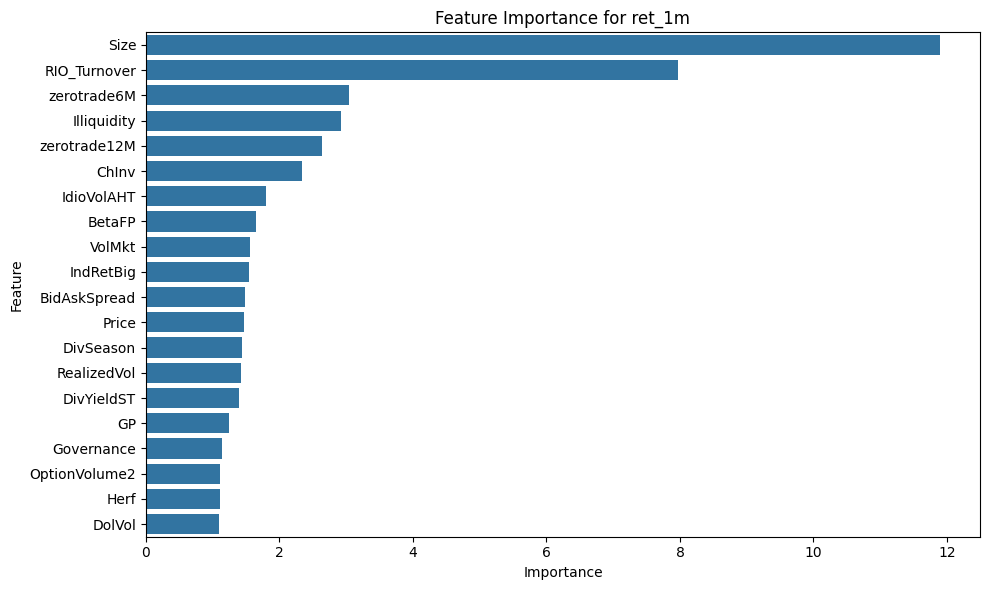

In [90]:
import seaborn as sns
# plot feature importance for ret_1m
x = features_importance["ret_1m"].keys()
y = features_importance["ret_1m"].values()
# select top 20 features based on y values
df_features_importance = pd.DataFrame({"feature": x, "importance": y})
df_features_importance = df_features_importance.sort_values(
    by="importance", ascending=False
).head(20)
plt.figure(figsize=(10, 6))
sns.barplot(x="importance", y="feature", data=df_features_importance)
plt.title("Feature Importance for ret_1m")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [92]:
df_train[df_train["yyyymm"] == 199001]

,permno,yyyymm,ret,ret_1m,ret_3m,ret_6m,AbnormalAccruals,Accruals,AccrualsBM,Activism1,...,skew1,SP,Spinoff,UpRecomm,VarCF,VolMkt,VolumeTrend,rank_score,rank_ret_1m,rank_rank_score
0,10401,199001,-0.142857,0.019231,-0.044643,-0.038961,-0.060983,-0.067248,NaN,NaN,...,NaN,1.239077,0.0,NaN,0.020726,0.036521,0.001023,20.3,21.0,29.0
1,10604,199001,-0.007856,0.038462,-0.035792,0.101064,-0.021692,0.000362,NaN,NaN,...,NaN,0.958112,0.0,NaN,0.001901,0.035447,-0.015070,14.6,11.0,40.0
2,11308,199001,-0.108414,0.023594,0.020067,0.022535,0.014099,-0.017921,NaN,NaN,...,NaN,0.354680,0.0,NaN,0.000208,0.035174,0.007244,43.4,20.0,3.0
3,11703,199001,-0.076220,0.046865,-0.029316,0.077922,-0.016629,-0.075618,NaN,NaN,...,NaN,1.228738,0.0,NaN,0.001132,0.041459,0.006132,15.3,7.0,36.5
4,11754,199001,-0.072948,0.000000,-0.057508,-0.058642,0.068047,-0.000802,NaN,NaN,...,NaN,1.377232,0.0,NaN,0.001662,0.085663,0.009512,27.8,28.5,19.5
5,11850,199001,-0.060000,0.012766,-0.018970,0.083551,-0.007984,-0.074210,NaN,NaN,...,NaN,1.352396,0.0,NaN,0.001065,0.021523,0.010419,4.4,24.0,49.0
6,12060,199001,-0.034884,-0.000482,-0.003891,0.034296,-0.067232,-0.282792,NaN,NaN,...,NaN,0.884832,0.0,NaN,0.000214,0.029794,0.016503,11.0,30.0,44.0
7,12079,199001,-0.014793,0.096096,-0.035422,-0.020997,-0.072254,0.284498,NaN,NaN,...,NaN,4.007481,0.0,NaN,0.001383,0.040324,0.005405,15.8,1.0,35.0
8,12490,199001,0.047809,0.065501,0.027091,-0.051064,0.079331,0.003072,NaN,NaN,...,NaN,1.045407,0.0,NaN,0.000343,0.064298,0.003066,15.2,5.0,38.0
9,13856,199001,-0.101563,0.017391,0.057884,-0.008052,-0.083682,-0.084671,NaN,NaN,...,NaN,0.860368,0.0,NaN,0.000239,0.047087,0.007521,34.1,22.0,15.0


In [ ]:
somme on 49 values ( rel / log_2(1+i))